# Landsat multi-day thumb gallery

This notebook enumerates every T1 scene under `s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/216/074/`, downloads their `thumb_large` previews into `../data/landsat/2025-216-074/`, and shows the previews with their capture dates.

In [52]:
import boto3
import json
import numpy as np
import rasterio
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime
import math

In [45]:
# one block is roughly a 20km resolution in google maps
# 216-073: sooretama and juparana on the right. country side of ES-north. GOOD ONE
# 215-073: lagoa juparana in the south, north reserva de sooretama. very north is nova vicosa
# 215-074: mostly coast, from lagoa juparana to guarapari
# 216-074: right side inland is anchieta. we can see caparaoh as well on the left
# 217-074: parque estadual do rio doce and araponga to the sourh

# 214-067: some coast, not identified


aws_registry_url = "https://registry.opendata.aws/usgs-landsat/index.html"
bucket_name = "usgs-landsat"
collection_prefix = "collection02/level-2/standard/oli-tirs/2025/216/073/"
requester_pays_args = {"RequestPayer": "requester"}

s3_client = boto3.client("s3")

local_data_root = Path("../data/landsat")
local_collection_dir = local_data_root / "2025-216-073"
local_collection_dir.mkdir(parents=True, exist_ok=True)

print(f"Prepared local folder: {local_collection_dir.resolve()}")
print(f"Listing T1 scenes beneath: s3://{bucket_name}/{collection_prefix}")

Prepared local folder: /Volumes/workplace/Projects/carbono-data-collection/data/landsat/2025-216-073
Listing T1 scenes beneath: s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/216/073/


In [46]:
thumb_assets = []
seen_scene_ids = set()
paginator = s3_client.get_paginator("list_objects_v2")

for page in paginator.paginate(Bucket=bucket_name, Prefix=collection_prefix, **requester_pays_args):
    for obj in page.get("Contents", []):
        key = obj["Key"]
        if not key.endswith("_thumb_large.jpg") and not key.endswith("_thumb_large.jpeg"):
            continue
        if "_T1/" not in key:
            continue
        pieces = key.split("/")
        if len(pieces) < 2:
            continue
        scene_id = pieces[-2]
        if scene_id in seen_scene_ids:
            continue
        seen_scene_ids.add(scene_id)
        scene_tokens = scene_id.split("_")
        capture_date = None
        if len(scene_tokens) > 3:
            try:
                capture_date = datetime.strptime(scene_tokens[3], "%Y%m%d")
            except ValueError:
                capture_date = None
        thumb_assets.append({"key": key, "scene_id": scene_id, "capture_date": capture_date})

thumb_assets.sort(key=lambda item: item["capture_date"] or datetime.min)
print(f"Found {len(thumb_assets)} T1 thumbnails")
for asset in thumb_assets:
    date_label = asset["capture_date"].strftime("%Y-%m-%d") if asset["capture_date"] else "unknown"
    print(f" - {asset['scene_id']} (captured {date_label})")

Found 28 T1 thumbnails
 - LC09_L2SP_216073_20250124_20250128_02_T1 (captured 2025-01-24)
 - LC08_L2SP_216073_20250201_20250208_02_T1 (captured 2025-02-01)
 - LC09_L2SP_216073_20250209_20250210_02_T1 (captured 2025-02-09)
 - LC08_L2SP_216073_20250217_20250226_02_T1 (captured 2025-02-17)
 - LC09_L2SP_216073_20250225_20250227_02_T1 (captured 2025-02-25)
 - LC08_L2SP_216073_20250305_20250312_02_T1 (captured 2025-03-05)
 - LC09_L2SP_216073_20250313_20250314_02_T1 (captured 2025-03-13)
 - LC08_L2SP_216073_20250321_20250327_02_T1 (captured 2025-03-21)
 - LC09_L2SP_216073_20250329_20250330_02_T1 (captured 2025-03-29)
 - LC08_L2SP_216073_20250406_20250412_02_T1 (captured 2025-04-06)
 - LC09_L2SP_216073_20250414_20250415_02_T1 (captured 2025-04-14)
 - LC09_L2SP_216073_20250516_20250517_02_T1 (captured 2025-05-16)
 - LC08_L2SP_216073_20250524_20250602_02_T1 (captured 2025-05-24)
 - LC08_L2SP_216073_20250609_20250618_02_T1 (captured 2025-06-09)
 - LC09_L2SP_216073_20250617_20250618_02_T1 (captured

In [47]:
metadata_keys = []
for asset in thumb_assets:
    scene_id = asset["scene_id"]
    metadata_key = f"{collection_prefix}{scene_id}/{scene_id}_MTL.json"
    metadata_keys.append(metadata_key)

if metadata_keys:
    print("Discovered metadata files:")
    for key in metadata_keys:
        print(f" - s3://{bucket_name}/{key}")
else:
    print("No metadata files found for this prefix.")


Discovered metadata files:
 - s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/216/073/LC09_L2SP_216073_20250124_20250128_02_T1/LC09_L2SP_216073_20250124_20250128_02_T1_MTL.json
 - s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/216/073/LC08_L2SP_216073_20250201_20250208_02_T1/LC08_L2SP_216073_20250201_20250208_02_T1_MTL.json
 - s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/216/073/LC09_L2SP_216073_20250209_20250210_02_T1/LC09_L2SP_216073_20250209_20250210_02_T1_MTL.json
 - s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/216/073/LC08_L2SP_216073_20250217_20250226_02_T1/LC08_L2SP_216073_20250217_20250226_02_T1_MTL.json
 - s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/216/073/LC09_L2SP_216073_20250225_20250227_02_T1/LC09_L2SP_216073_20250225_20250227_02_T1_MTL.json
 - s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/216/073/LC08_L2SP_216073_20250305_20250312_02_T1/LC08_L2SP_216073_20250305_20250312_02_T

In [48]:
if not metadata_keys:
    raise RuntimeError("No metadata files available to inspect.")

sample_metadata_key = metadata_keys[0]
response = s3_client.get_object(Bucket=bucket_name, Key=sample_metadata_key, **requester_pays_args)
sample_metadata = json.loads(response["Body"].read())

print(f"Showing metadata content for s3://{bucket_name}/{sample_metadata_key}")
print(json.dumps(sample_metadata, indent=2))


Showing metadata content for s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/216/073/LC09_L2SP_216073_20250124_20250128_02_T1/LC09_L2SP_216073_20250124_20250128_02_T1_MTL.json
{
  "LANDSAT_METADATA_FILE": {
    "PRODUCT_CONTENTS": {
      "ORIGIN": "Image courtesy of the U.S. Geological Survey",
      "DIGITAL_OBJECT_IDENTIFIER": "https://doi.org/10.5066/P9OGBGM6",
      "LANDSAT_PRODUCT_ID": "LC09_L2SP_216073_20250124_20250128_02_T1",
      "PROCESSING_LEVEL": "L2SP",
      "COLLECTION_NUMBER": "02",
      "COLLECTION_CATEGORY": "T1",
      "OUTPUT_FORMAT": "GEOTIFF",
      "FILE_NAME_BAND_1": "LC09_L2SP_216073_20250124_20250128_02_T1_SR_B1.TIF",
      "FILE_NAME_BAND_2": "LC09_L2SP_216073_20250124_20250128_02_T1_SR_B2.TIF",
      "FILE_NAME_BAND_3": "LC09_L2SP_216073_20250124_20250128_02_T1_SR_B3.TIF",
      "FILE_NAME_BAND_4": "LC09_L2SP_216073_20250124_20250128_02_T1_SR_B4.TIF",
      "FILE_NAME_BAND_5": "LC09_L2SP_216073_20250124_20250128_02_T1_SR_B5.TIF",
      "FIL

In [49]:
for asset in thumb_assets:
    filename = asset["key"].split("/")[-1]
    local_path = local_collection_dir / filename
    asset["local_path"] = local_path
    if local_path.exists():
        print(f"Skipping existing {filename}")
        continue
    s3_client.download_file(Bucket=bucket_name, Key=asset["key"], Filename=str(local_path), ExtraArgs=requester_pays_args)
    print(f"Downloaded {filename} -> {local_path}")

if not thumb_assets:
    raise RuntimeError("No T1 thumb_large files were found for the requested path.")

Downloaded LC09_L2SP_216073_20250124_20250128_02_T1_thumb_large.jpeg -> ../data/landsat/2025-216-073/LC09_L2SP_216073_20250124_20250128_02_T1_thumb_large.jpeg
Downloaded LC08_L2SP_216073_20250201_20250208_02_T1_thumb_large.jpeg -> ../data/landsat/2025-216-073/LC08_L2SP_216073_20250201_20250208_02_T1_thumb_large.jpeg
Downloaded LC09_L2SP_216073_20250209_20250210_02_T1_thumb_large.jpeg -> ../data/landsat/2025-216-073/LC09_L2SP_216073_20250209_20250210_02_T1_thumb_large.jpeg
Downloaded LC08_L2SP_216073_20250217_20250226_02_T1_thumb_large.jpeg -> ../data/landsat/2025-216-073/LC08_L2SP_216073_20250217_20250226_02_T1_thumb_large.jpeg
Downloaded LC09_L2SP_216073_20250225_20250227_02_T1_thumb_large.jpeg -> ../data/landsat/2025-216-073/LC09_L2SP_216073_20250225_20250227_02_T1_thumb_large.jpeg
Downloaded LC08_L2SP_216073_20250305_20250312_02_T1_thumb_large.jpeg -> ../data/landsat/2025-216-073/LC08_L2SP_216073_20250305_20250312_02_T1_thumb_large.jpeg
Downloaded LC09_L2SP_216073_20250313_20250314_

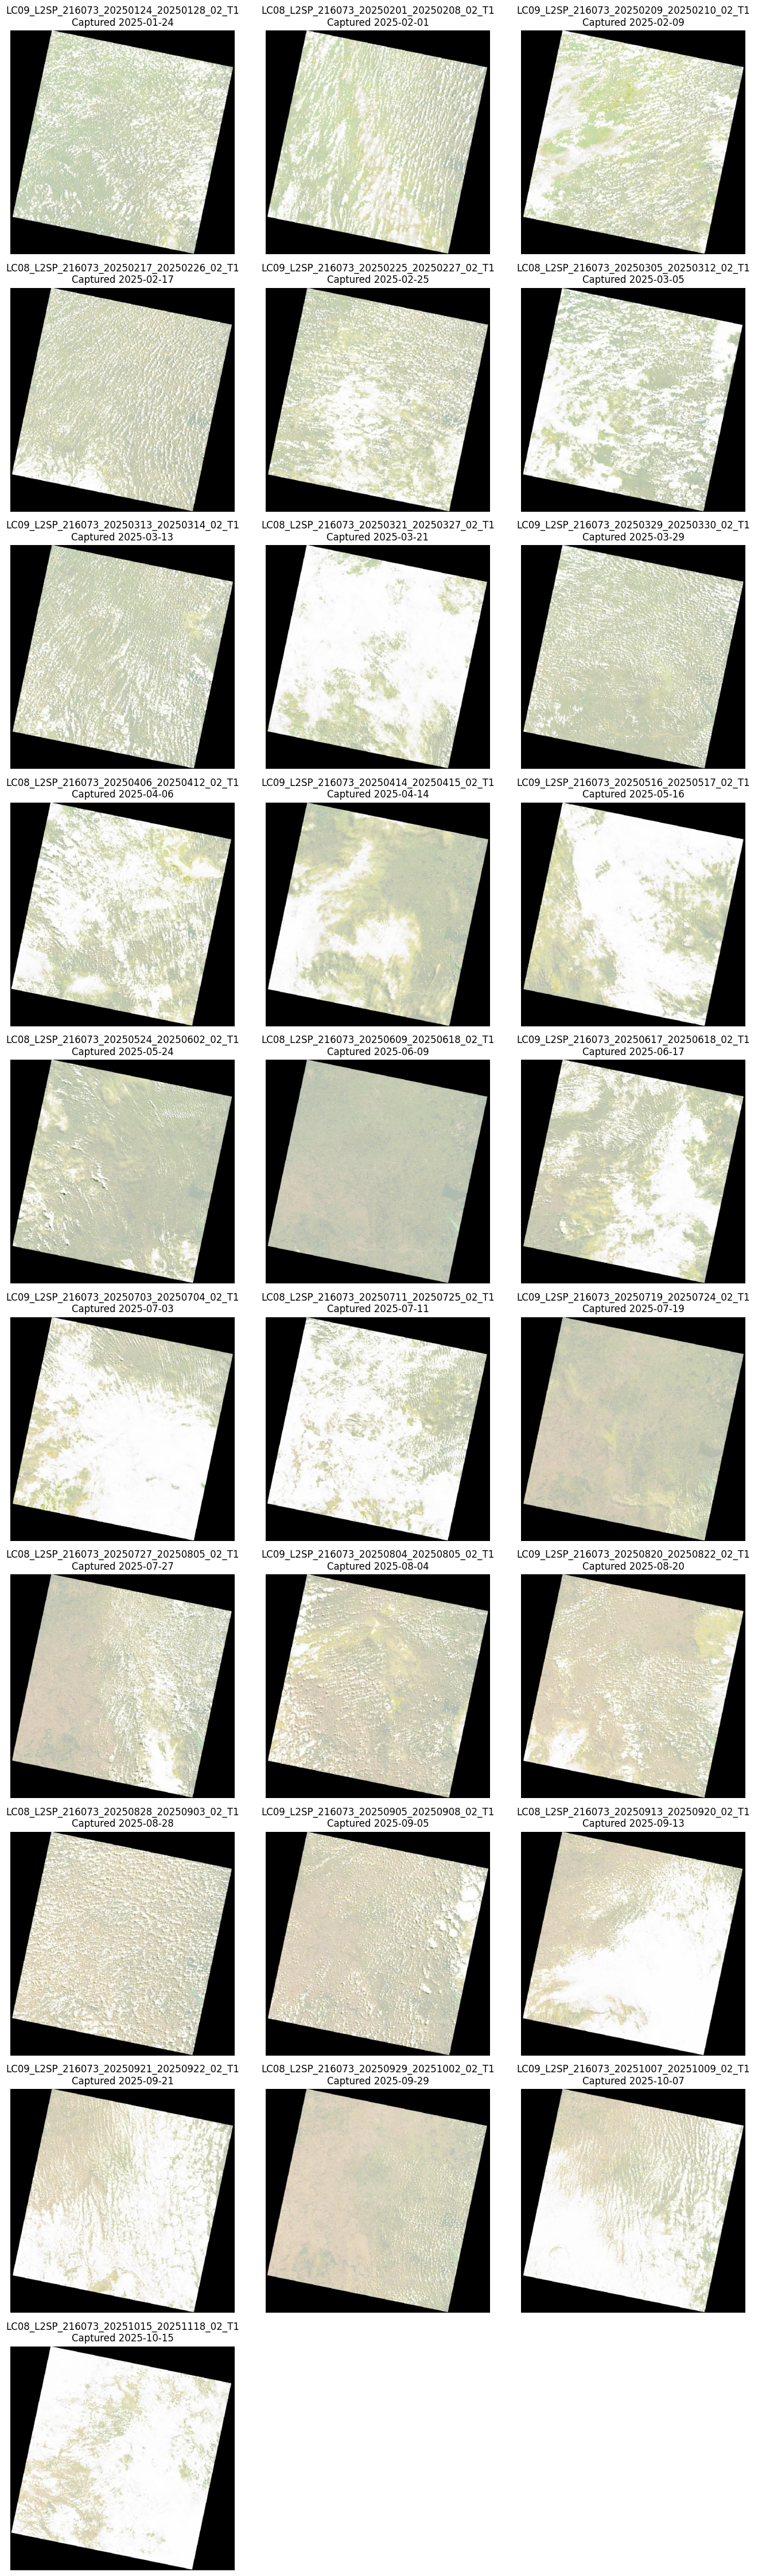

In [50]:
n_assets = len(thumb_assets)
n_cols = min(3, max(1, n_assets))
n_rows = math.ceil(n_assets / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax in axes[n_assets:]:
    ax.axis('off')

for ax, asset in zip(axes, thumb_assets):
    image = plt.imread(asset["local_path"])
    date_label = asset["capture_date"].strftime("%Y-%m-%d") if asset["capture_date"] else "unknown date"
    ax.imshow(image)
    ax.set_title(f"{asset['scene_id']}\nCaptured {date_label}")
    ax.axis('off')

plt.tight_layout()

# Quality assurance

checking the cloud index of each image to determine the best one per year

In [53]:
qa_results = []

for asset in thumb_assets:
    scene_id = asset["scene_id"]
    qa_key = f"{collection_prefix}{scene_id}/{scene_id}_QA_PIXEL.TIF"
    local_qa_path = local_collection_dir / f"{scene_id}_QA_PIXEL.TIF"
    asset["qa_path"] = local_qa_path

    if not local_qa_path.exists():
        try:
            s3_client.download_file(Bucket=bucket_name, Key=qa_key, Filename=str(local_qa_path), ExtraArgs=requester_pays_args)
            print(f"Downloaded QA file {local_qa_path.name}")
        except s3_client.exceptions.NoSuchKey:
            print(f"QA metadata not found for {scene_id} at {qa_key}")
            continue
        except Exception as exc:
            print(f"Failed to download QA file for {scene_id}: {exc}")
            continue
    else:
        print(f"Using cached QA file {local_qa_path.name}")

    try:
        with rasterio.open(local_qa_path) as src:
            qa_array = src.read(1)
    except Exception as exc:
        print(f"Failed to read {local_qa_path.name}: {exc}")
        continue

    fill_mask = (qa_array & 1) != 0
    dilated_mask = (qa_array & (1 << 1)) != 0
    cirrus_mask = (qa_array & (1 << 2)) != 0
    cloud_mask = (qa_array & (1 << 3)) != 0
    shadow_mask = (qa_array & (1 << 4)) != 0

    valid_pixels = qa_array.size - int(fill_mask.sum())
    if valid_pixels <= 0:
        print(f"No valid pixels in {local_qa_path.name}")
        continue

    problem_mask = dilated_mask | cirrus_mask | cloud_mask | shadow_mask
    cloud_pixels = int((problem_mask & (~fill_mask)).sum())
    quality_score = 1 - (cloud_pixels / valid_pixels)

    qa_results.append({"scene_id": scene_id, "local_path": local_qa_path, "quality_score": quality_score})
    print(f"{scene_id} -> quality score {quality_score:.4f}")

if qa_results:
    qa_results.sort(key=lambda item: item["quality_score"], reverse=True)
    best_asset = qa_results[0]
    print(f"Best QA_PIXEL file: {best_asset['local_path'].name} (score {best_asset['quality_score']:.4f})")
else:
    print("No QA_PIXEL files were successfully analyzed.")


Using cached QA file LC09_L2SP_216073_20250124_20250128_02_T1_QA_PIXEL.TIF
LC09_L2SP_216073_20250124_20250128_02_T1 -> quality score 0.3482
Using cached QA file LC08_L2SP_216073_20250201_20250208_02_T1_QA_PIXEL.TIF
LC08_L2SP_216073_20250201_20250208_02_T1 -> quality score 0.1719
Using cached QA file LC09_L2SP_216073_20250209_20250210_02_T1_QA_PIXEL.TIF
LC09_L2SP_216073_20250209_20250210_02_T1 -> quality score 0.1541
Using cached QA file LC08_L2SP_216073_20250217_20250226_02_T1_QA_PIXEL.TIF
LC08_L2SP_216073_20250217_20250226_02_T1 -> quality score 0.3914
Using cached QA file LC09_L2SP_216073_20250225_20250227_02_T1_QA_PIXEL.TIF
LC09_L2SP_216073_20250225_20250227_02_T1 -> quality score 0.2452
Using cached QA file LC08_L2SP_216073_20250305_20250312_02_T1_QA_PIXEL.TIF
LC08_L2SP_216073_20250305_20250312_02_T1 -> quality score 0.2054
Using cached QA file LC09_L2SP_216073_20250313_20250314_02_T1_QA_PIXEL.TIF
LC09_L2SP_216073_20250313_20250314_02_T1 -> quality score 0.3750
Using cached QA file